In [2]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import PIL.Image
import av
import io

## 1 Audio — Representation & Playback

In [3]:
SR = 44100  # sampling rate: samples per second

def sinewave(frequency, amplitude=1, length=1, rate=SR):
    x = np.linspace(0, 2 * np.pi * frequency * length, round(length * rate))
    return np.sin(x) * amplitude

audio = sinewave(440)
print(f"{len(audio)} samples at {SR} Hz  →  {len(audio)/SR:.1f} second")
display(Audio(audio, rate=SR))

44100 samples at 44100 Hz  →  1.0 second


In [4]:
audio_mix = sinewave(440) + sinewave(880, amplitude=0.5)
audio_mix /= np.max(np.abs(audio_mix))   # normalise to [-1, 1]
display(Audio(audio_mix, rate=SR))

## 2 Waveform

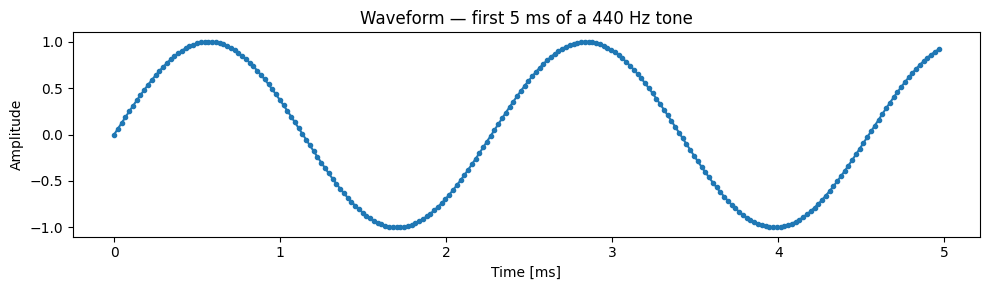

In [5]:
waveform = audio[: round(SR * 0.005)]   # first 5 ms
time_ms  = np.arange(len(waveform)) / SR * 1000

plt.figure(figsize=(10, 3))
plt.plot(time_ms, waveform, marker='o', markersize=3)
plt.xlabel('Time [ms]')
plt.ylabel('Amplitude')
plt.title('Waveform — first 5 ms of a 440 Hz tone')
plt.tight_layout()
plt.show()


## 3 Spectrogram

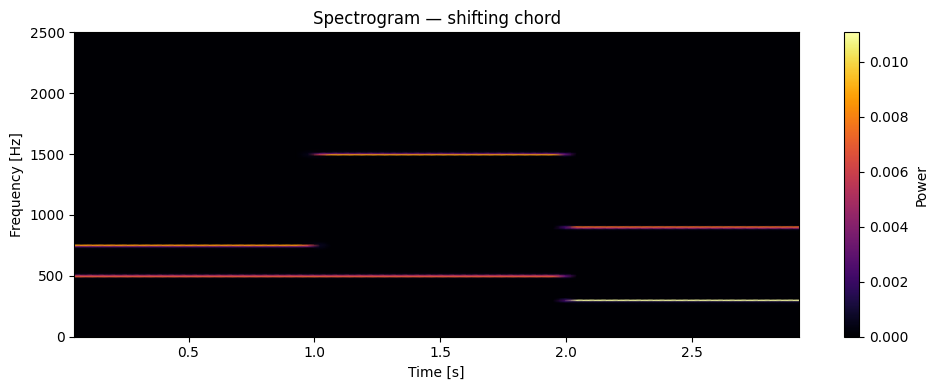

In [6]:
# Build a 3-second signal: chord changes every second
seg1 = sinewave(500, length=1) + sinewave(750, length=1)   # 0-1s
seg2 = sinewave(500, length=1) + sinewave(1500, length=1)  # 1-2s
seg3 = sinewave(300, length=1) + sinewave(900, length=1)   # 2-3s
signal = np.concatenate([seg1, seg2, seg3])
signal /= np.max(np.abs(signal))

display(Audio(signal, rate=SR))

f, t, Sxx = scipy.signal.spectrogram(signal, fs=SR, nperseg=4096, noverlap=2048)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, Sxx, shading='gouraud', cmap='inferno')
plt.ylim(0, 2500)
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram — shifting chord')
plt.colorbar(label='Power')
plt.tight_layout()
plt.show()


## 4 Frequency Filtering

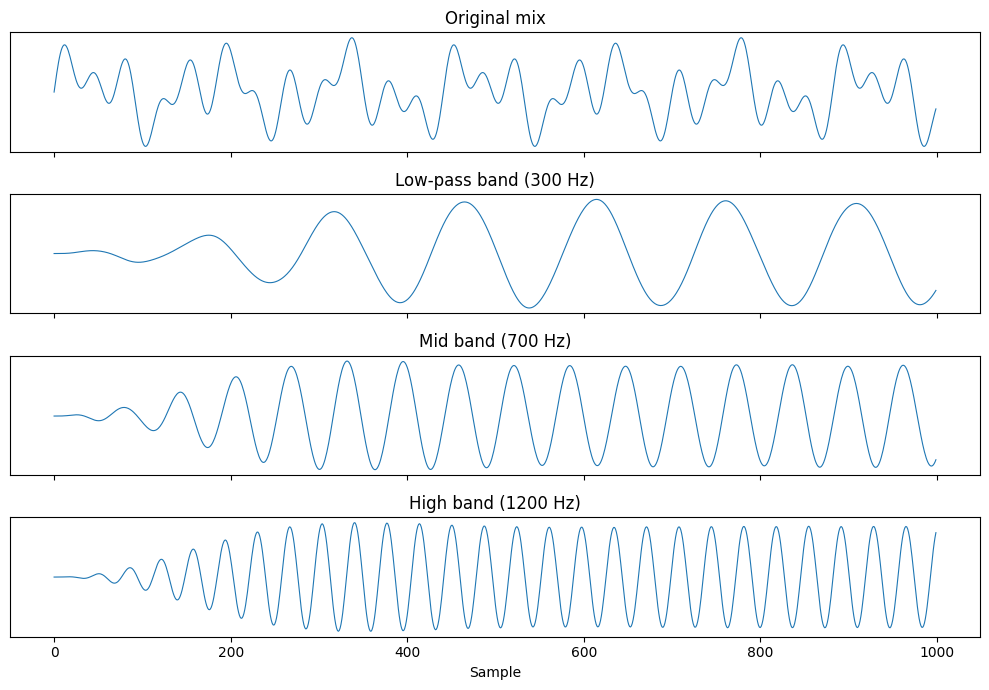

Original:


Low band:


Mid band:


High band:


In [7]:
def bandpass_filter(data, lowcut, highcut, sr, order=3):
    b, a = scipy.signal.butter(order, [lowcut, highcut], fs=sr, btype='band')
    return scipy.signal.lfilter(b, a, data)

# Mix of 300, 700, 1200 Hz
rich = sinewave(300) + sinewave(700) + sinewave(1200)

filtered_low  = bandpass_filter(rich, 250,  400, SR)   # keeps 300 Hz
filtered_mid  = bandpass_filter(rich, 600,  800, SR)   # keeps 700 Hz
filtered_high = bandpass_filter(rich, 1100, 1300, SR)  # keeps 1200 Hz

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
labels = ['Original mix', 'Low-pass band (300 Hz)', 'Mid band (700 Hz)', 'High band (1200 Hz)']
signals = [rich, filtered_low, filtered_mid, filtered_high]
for ax, sig, lbl in zip(axes, signals, labels):
    ax.plot(sig[:1000], linewidth=0.8)
    ax.set_title(lbl)
    ax.set_yticks([])
plt.xlabel('Sample')
plt.tight_layout()
plt.show()

print("Original:"); display(Audio(rich, rate=SR))
print("Low band:"); display(Audio(filtered_low,  rate=SR))
print("Mid band:"); display(Audio(filtered_mid,  rate=SR))
print("High band:"); display(Audio(filtered_high, rate=SR))


## 5 Audio Channels — Stereo → Mono

In [8]:
# Simulate stereo: left channel = 300 Hz, right = 700 Hz
left  = sinewave(300)
right = sinewave(700)
stereo = np.stack([left, right], axis=1)   # shape (44100, 2)
print("Stereo shape:", stereo.shape)

# Convert to mono by averaging channels
mono = stereo.mean(axis=1)
print("Mono shape:  ", mono.shape)

print("Stereo (hear both):")
display(Audio(stereo.T, rate=SR))
print("Mono (mixed):")
display(Audio(mono, rate=SR))


Stereo shape: (44100, 2)
Mono shape:   (44100,)
Stereo (hear both):


Mono (mixed):


## 6 Image Data — 3D Arrays & RGB

Array shape: (200, 300, 3)  dtype: uint8


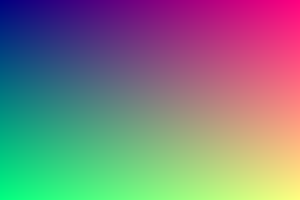

In [9]:
# Generate a synthetic RGB image with gradients
H, W = 200, 300
arr = np.zeros((H, W, 3), dtype=np.uint8)
arr[:, :, 0] = np.linspace(0, 255, W)                    # red  → left to right
arr[:, :, 1] = np.linspace(0, 255, H)[:, np.newaxis]     # green → top to bottom
arr[:, :, 2] = 128                                        # blue  → constant

img = PIL.Image.fromarray(arr)
print("Array shape:", arr.shape, " dtype:", arr.dtype)
display(img)


## 7 Color Channels

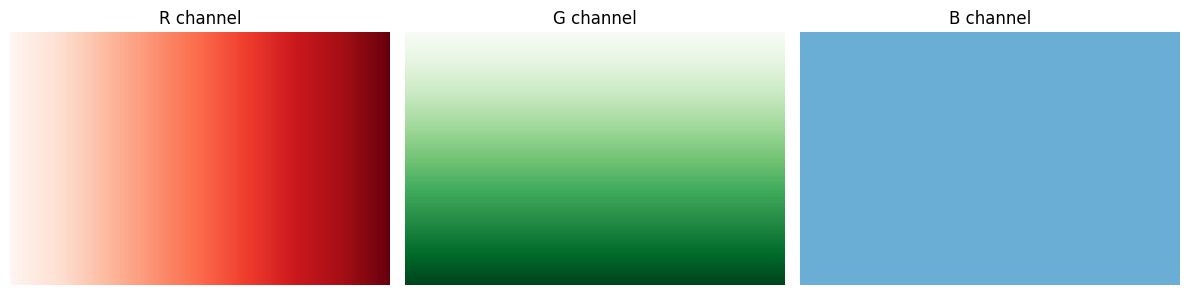

In [10]:
r = arr[:, :, 0]
g = arr[:, :, 1]
b = arr[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(r, cmap='Reds',   vmin=0, vmax=255); axes[0].set_title('R channel')
axes[1].imshow(g, cmap='Greens', vmin=0, vmax=255); axes[1].set_title('G channel')
axes[2].imshow(b, cmap='Blues',  vmin=0, vmax=255); axes[2].set_title('B channel')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


## 8 Crop, Resize, Rotate

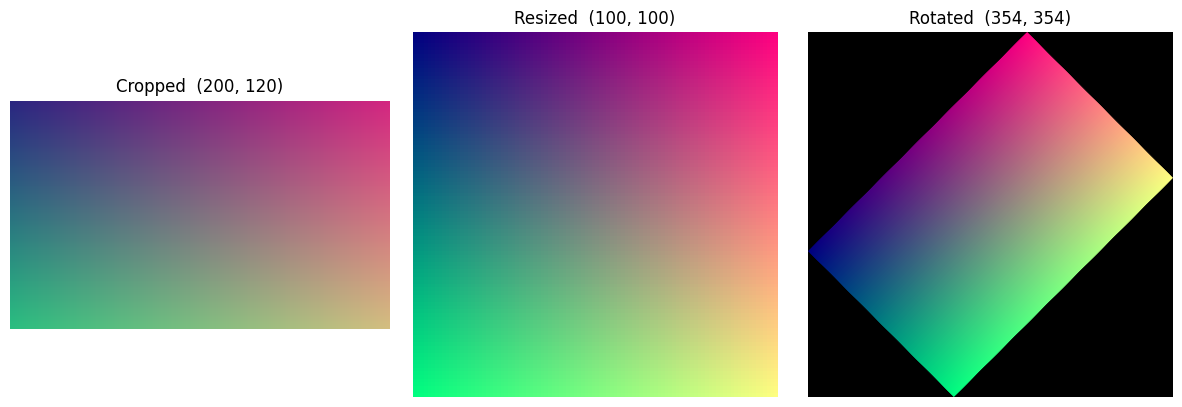

In [11]:
cropped = img.crop((50, 30, 250, 150))     # (left, top, right, bottom)
resized = img.resize((100, 100))
rotated = img.rotate(45, expand=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.asarray(cropped)); axes[0].set_title(f'Cropped  {cropped.size}')
axes[1].imshow(np.asarray(resized)); axes[1].set_title(f'Resized  {resized.size}')
axes[2].imshow(np.asarray(rotated)); axes[2].set_title(f'Rotated  {rotated.size}')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


## 9 RGBA — Alpha Channel

Shape: (200, 300, 4)


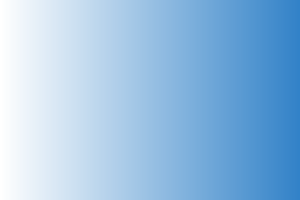

In [12]:
# Add transparency: pixels on the right half are semi-transparent
rgba = np.zeros((200, 300, 4), dtype=np.uint8)
rgba[:, :, 0] = 50                              # R
rgba[:, :, 1] = 130                             # G
rgba[:, :, 2] = 200                             # B
rgba[:, :, 3] = np.linspace(0, 255, 300)        # alpha: left=transparent, right=opaque

rgba_img = PIL.Image.fromarray(rgba, mode='RGBA')
print("Shape:", np.asarray(rgba_img).shape)     # (200, 300, 4)
display(rgba_img)


## 10 Video — Generate a Synthetic MP4

In [13]:
VIDEO_PATH = "demo.mp4"
FPS        = 24
N_FRAMES   = 72   # 3 seconds

out = av.open(VIDEO_PATH, 'w')
stream = out.add_stream('h264', rate=FPS)
stream.width, stream.height = 320, 240
stream.pix_fmt = 'yuv420p'

for i in range(N_FRAMES):
    frame_arr = np.zeros((240, 320, 3), dtype=np.uint8)
    # Red sweeps across the frame
    frame_arr[:, :, 0] = int(i / N_FRAMES * 255)
    # Blue sweeps the other way
    frame_arr[:, :, 2] = 255 - int(i / N_FRAMES * 255)
    # Diagonal green stripe that moves
    offset = int(i / N_FRAMES * 320)
    xs = np.arange(320)
    ys = np.clip((xs - offset) % 240, 0, 239)
    for x, y in zip(xs, ys):
        frame_arr[y, x, 1] = 200

    frame = av.VideoFrame.from_ndarray(frame_arr, format='rgb24')
    for pkt in stream.encode(frame): out.mux(pkt)

for pkt in stream.encode(None): out.mux(pkt)
out.close()
print(f"Written: {VIDEO_PATH}")

from IPython.display import Video
display(Video(VIDEO_PATH, width=480))


Written: demo.mp4
